<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 107.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 51.1 MB/s eta 0:00:00


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [5]:
## Write your code here
df.shape
df.dtypes

ResponseId               int64
MainBranch                 str
Age                        str
Employment                 str
RemoteWork                 str
                        ...   
JobSatPoints_11        float64
SurveyLength               str
SurveyEase                 str
ConvertedCompYearly    float64
JobSat                 float64
Length: 114, dtype: object

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [10]:
## Write your code here
# Count missing values per column
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts

categorical_cols = ['Employment', 'JobSat', 'RemoteWork', 'EdLevel', 'Country']
#Categorical Columns (Employment, JobSat, RemoteWork, EdLevel, Country)Fill with mode (most common value)
categorical_cols = ['Employment', 'JobSat', 'RemoteWork', 'EdLevel', 'Country']

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])



#Numeric Columns (YearsCodePro, ConvertedCompYearly, JobSatPoints_1) Best approach: Fill with median (robust to outliers)
numeric_cols = ['YearsCodePro', 'ConvertedCompYearly', 'JobSatPoints_1']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())



#Remove rows only when absolutely necessary.If a row is missing too many critical fields, you can drop it:
df = df.dropna(subset=['Employment', 'JobSat', 'RemoteWork'], how='any')
#drop rows with more than 50% missing values:
#df = df[df.isna().mean(axis=1) < 0.5]
df.isna().sum()



ResponseId                 0
MainBranch                 0
Age                        0
Employment                 0
RemoteWork                 0
                       ...  
JobSatPoints_11        17909
SurveyLength            1234
SurveyEase              1199
ConvertedCompYearly        0
JobSat                     0
Length: 114, dtype: int64

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [16]:
## Write your code here
top_employment_counts = df['Employment'].value_counts().head(20)
top_employment_counts
job_sat_counts = df['JobSat'].value_counts().head(20)
job_sat_counts
years_codepro_counts = df['YearsCodePro'].value_counts().head(20)
years_codepro_counts

YearsCodePro
8.0     7938
2.0     3492
3.0     3463
5.0     3032
10.0    2795
4.0     2778
6.0     2473
7.0     2230
1.0     2100
12.0    1564
15.0    1410
9.0     1331
20.0    1308
11.0    1133
13.0     989
14.0     941
16.0     836
25.0     814
18.0     749
17.0     711
Name: count, dtype: int64

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


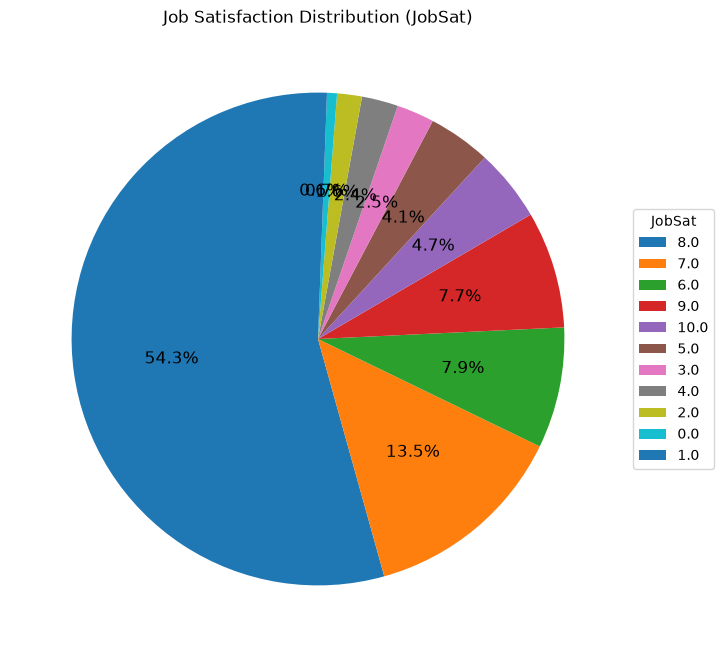

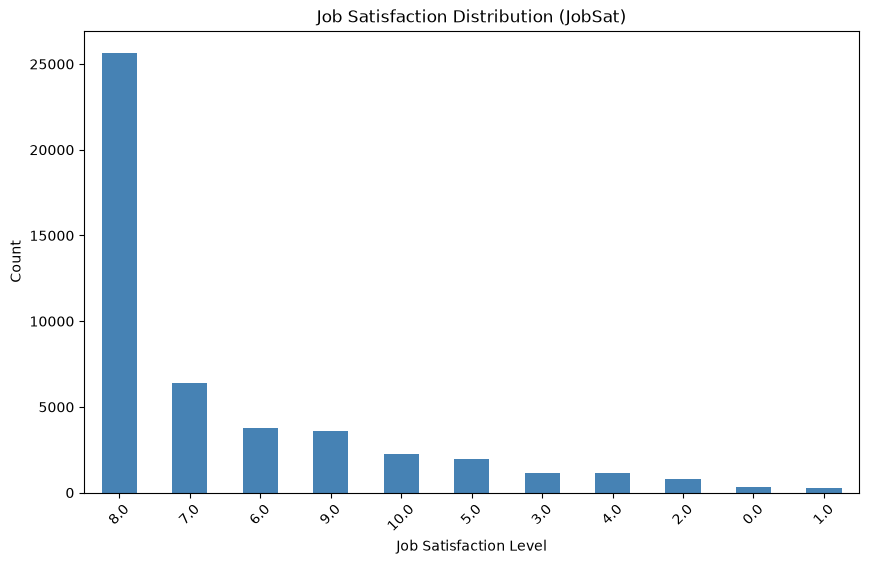

In [22]:
## Write your code here
df['JobSat'].value_counts()
df['JobSat'] = df['JobSat'].fillna(df['JobSat'].mode()[0])
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

job_counts = df['JobSat'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(
    job_counts.values,
    labels=None,                 # remove labels from slices
    autopct='%1.1f%%',           # show only percentages
    startangle=90,
    textprops={'fontsize': 12}
)

plt.legend(
    job_counts.index,
    title="JobSat",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title("Job Satisfaction Distribution (JobSat)")
plt.show()

import matplotlib.pyplot as plt

job_counts = df['JobSat'].value_counts()

plt.figure(figsize=(10,6))
job_counts.plot(kind='bar', color='steelblue')

plt.title("Job Satisfaction Distribution (JobSat)")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


<Figure size 1400x700 with 0 Axes>

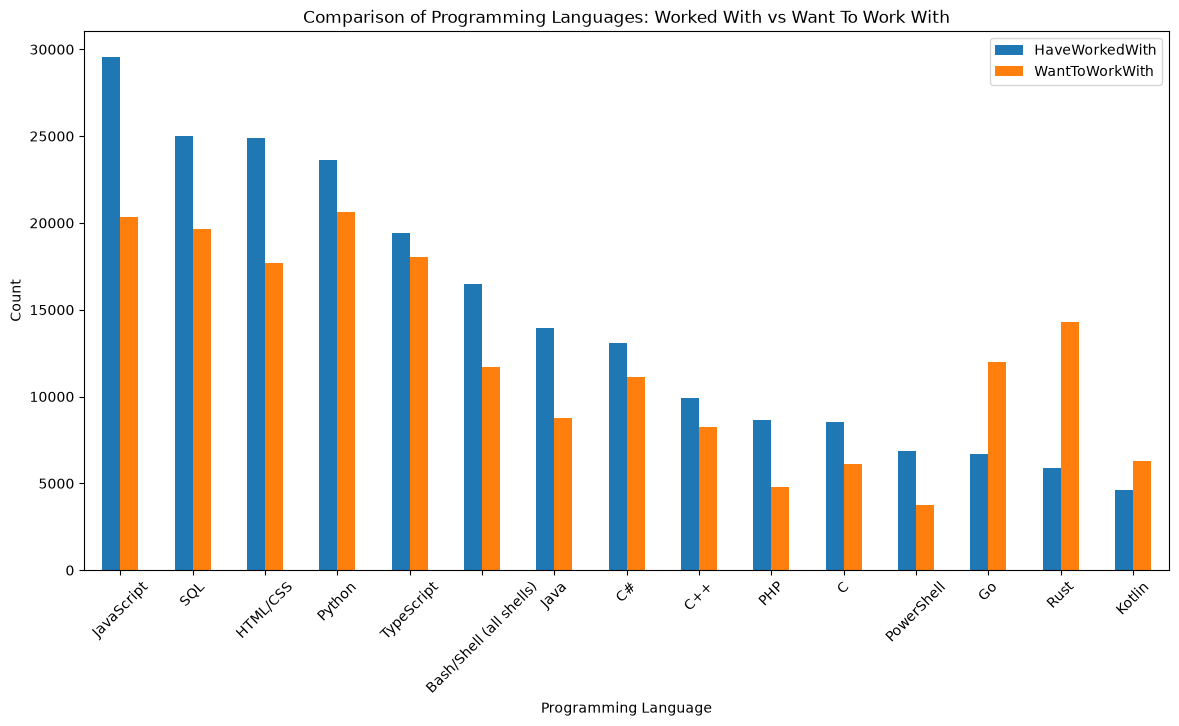

ModuleNotFoundError: No module named 'matplotlib_venn'

In [29]:
## Write your code here
#Split both columns into lists and explode them.
# Drop missing values
df_lang = df[['LanguageHaveWorkedWith', 'LanguageWantToWorkWith']].dropna()

# Split into lists
df_lang['HaveList'] = df_lang['LanguageHaveWorkedWith'].str.split(';')
df_lang['WantList'] = df_lang['LanguageWantToWorkWith'].str.split(';')

# Explode
df_have = df_lang.explode('HaveList')
df_have['HaveList'] = df_have['HaveList'].str.strip()

df_want = df_lang.explode('WantList')
df_want['WantList'] = df_want['WantList'].str.strip()
#count frequncies
have_counts = df_have['HaveList'].value_counts()
want_counts = df_want['WantList'].value_counts()
#Grouped bar chart
import pandas as pd
import matplotlib.pyplot as plt

# Combine into one DataFrame
compare_df = pd.DataFrame({
    'HaveWorkedWith': have_counts,
    'WantToWorkWith': want_counts
}).fillna(0)

# Plot top 15 languages
top_langs = compare_df.sort_values('HaveWorkedWith', ascending=False).head(15)

plt.figure(figsize=(14,7))
top_langs.plot(kind='bar', figsize=(14,7))

plt.title("Comparison of Programming Languages: Worked With vs Want To Work With")
plt.xlabel("Programming Language")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


from matplotlib_venn import venn2
import matplotlib.pyplot as plt

have_set = set(have_counts.index)
want_set = set(want_counts.index)

plt.figure(figsize=(8,8))
venn2([have_set, want_set], ('Have Worked With', 'Want To Work With'))
plt.title("Overlap Between Languages Worked With and Desired Languages")
plt.show()



### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


<Figure size 1600x800 with 0 Axes>

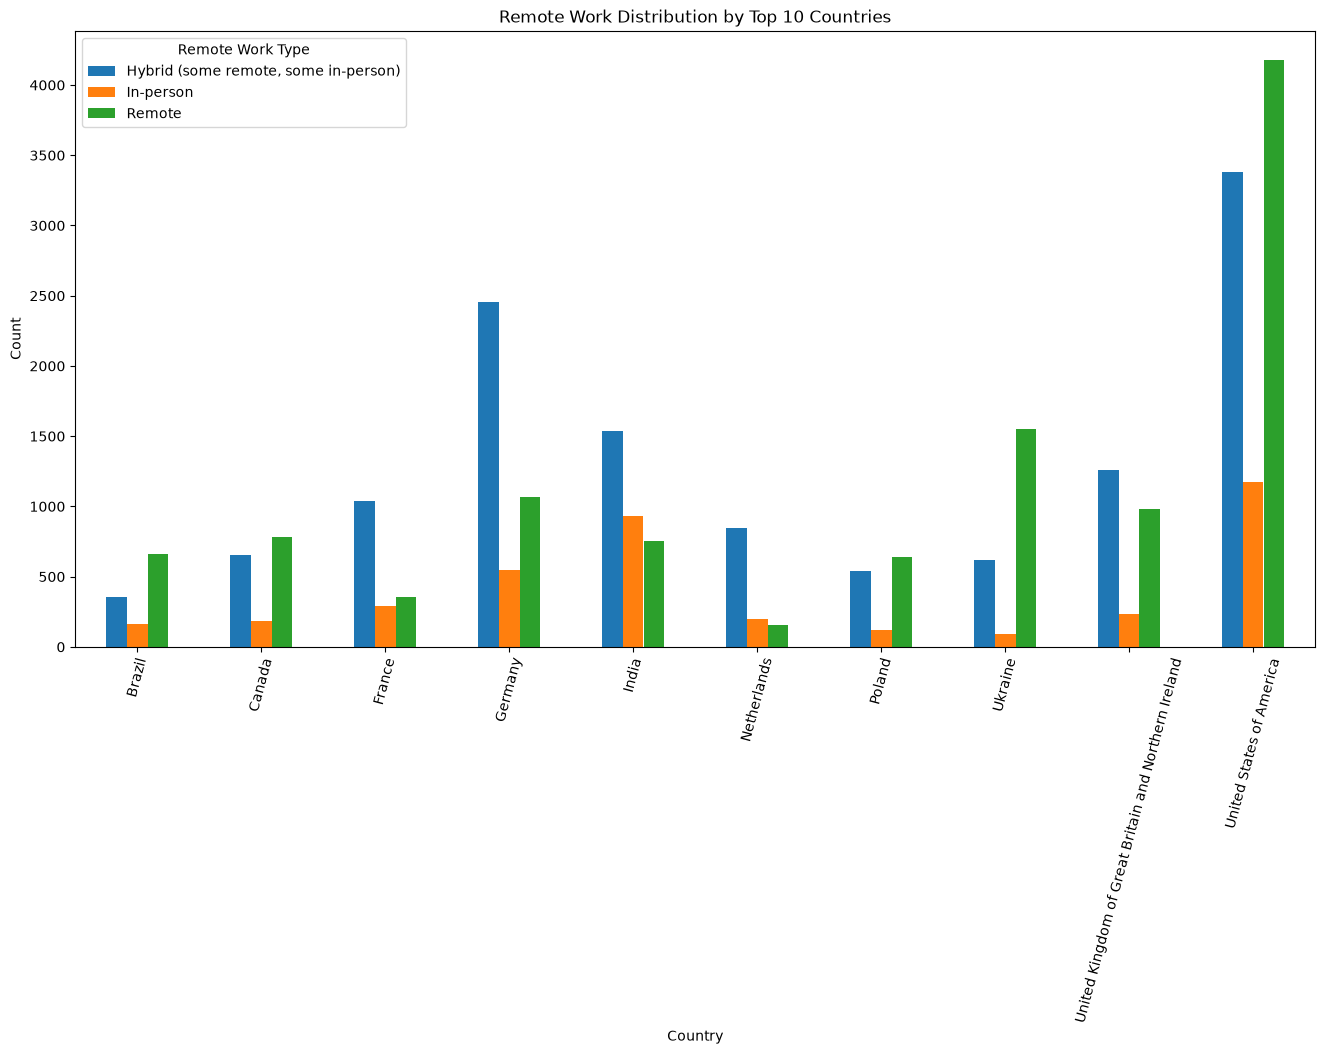

In [26]:
## Write your code here
df['RemoteWork'] = df['RemoteWork'].fillna(df['RemoteWork'].mode()[0])
df['Country'] = df['Country'].fillna(df['Country'].mode()[0])
import pandas as pd
import matplotlib.pyplot as plt

# Cross-tab: RemoteWork by Country
remote_region = pd.crosstab(df['Country'], df['RemoteWork'])

top10_countries = df['Country'].value_counts().head(10).index
df_top10 = df[df['Country'].isin(top10_countries)]

remote_region_top10 = pd.crosstab(df_top10['Country'], df_top10['RemoteWork'])

plt.figure(figsize=(16,8))
remote_region_top10.plot(kind='bar', figsize=(16,8))

plt.title("Remote Work Distribution by Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.legend(title="Remote Work Type")
plt.show()


### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


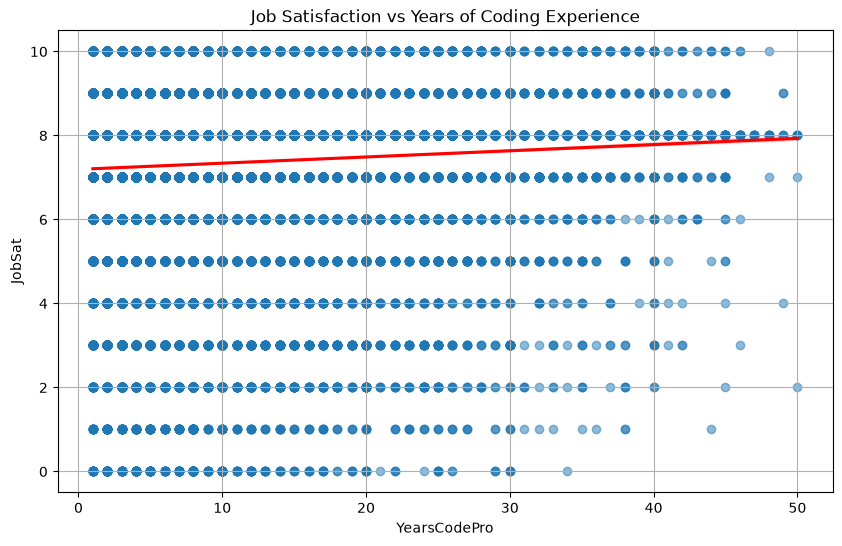

In [45]:
## Write your code here
# Map JobSat categories to numeric values
df['JobSat'] = pd.to_numeric(df['JobSat'], errors='coerce')
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
df_corr = df[['JobSat', 'YearsCodePro']].dropna()
df_corr.shape
df_corr.head()
pearson_corr = df_corr.corr(method='pearson')
spearman_corr = df_corr.corr(method='spearman')

pearson_corr.loc['JobSat', 'YearsCodePro'], spearman_corr.loc['JobSat', 'YearsCodePro']

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.regplot(
    x=df_corr['YearsCodePro'],
    y=df_corr['JobSat'],
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)

plt.title("Job Satisfaction vs Years of Coding Experience")
plt.xlabel("YearsCodePro")
plt.ylabel("JobSat")
plt.grid(True)
plt.show()





### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


<Figure size 1400x800 with 0 Axes>

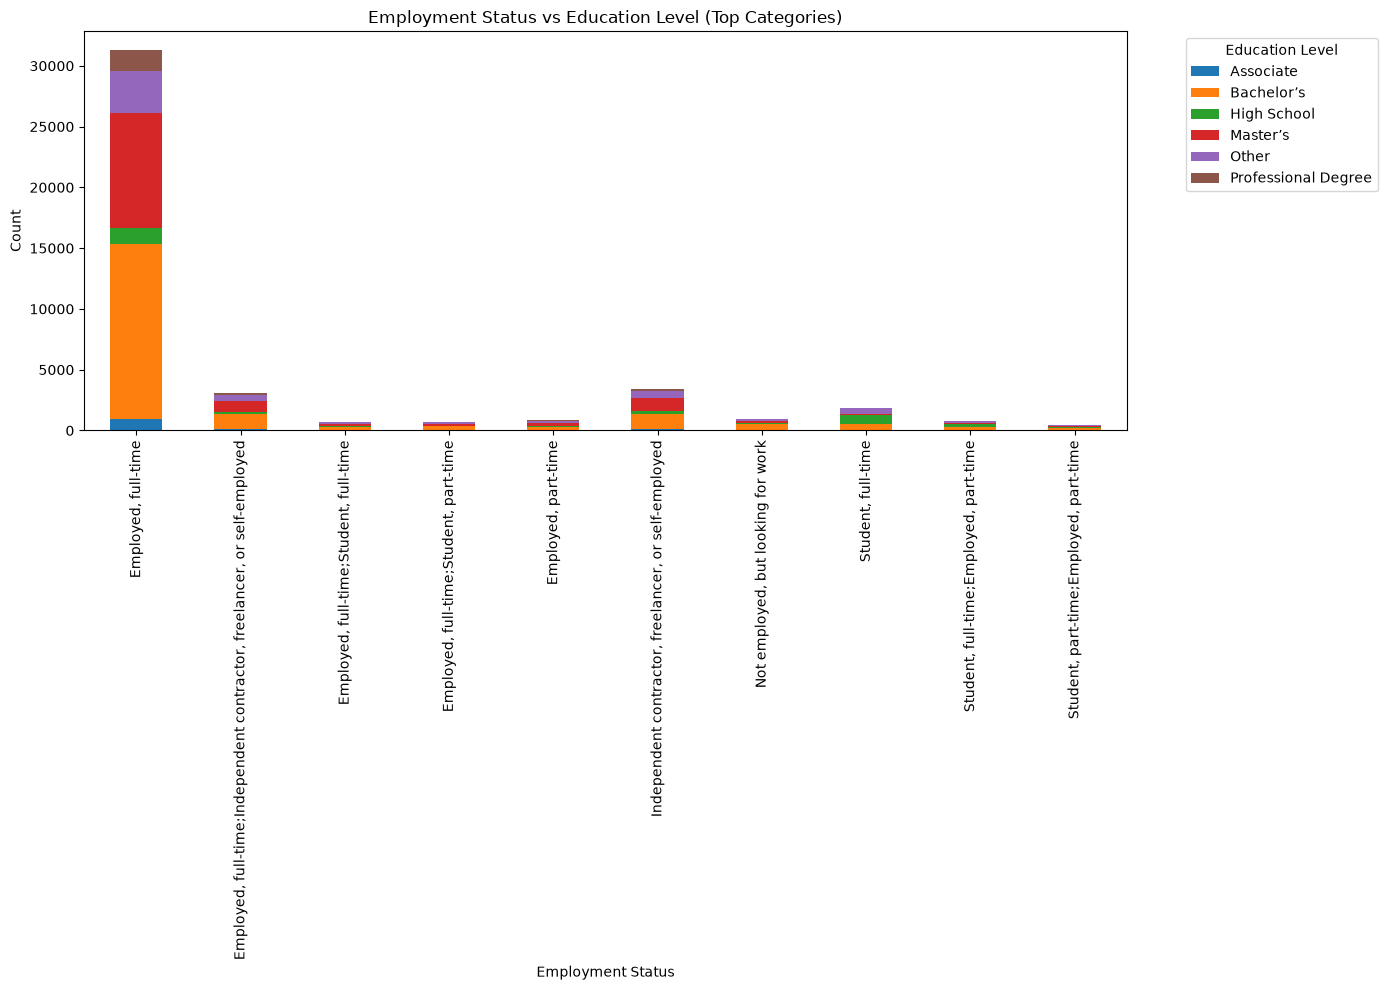

In [58]:
## Write your code here

#create with simplified categories
top_employment = df['Employment'].value_counts().head(10).index
df_top = df[df['Employment'].isin(top_employment)]


df['EdLevel_simple'] = df['EdLevel'].apply(simplify_edlevel)

# Cross-tab: Employment × Education Level
employment_edu = pd.crosstab(df_top['Employment'], df_top['EdLevel_simple'])


employment_edu

plt.figure(figsize=(14,8))
employment_edu.plot(kind='bar', stacked=True, figsize=(14,10))

plt.title("Employment Status vs Education Level (Top Categories)")
plt.xlabel("Employment Status")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.legend(title="Education Level", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()





### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [61]:
## Write your code here
df.to_csv("cleaned_data_lab13.csv", index=False)


### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
